In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("D:/Cars_Datasets_2025.csv", encoding = 'latin1')

In [4]:
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed (km/h),Performance(0 - 100 )KM/H,Cars Prices,Prices,Currency,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963.0,340.0,2.5 sec,1100000.00,1100000.0,$,plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563.0,250.0,5.3 sec,460000.00,460000.0,$,Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70.0,165.0,10.5 sec,"12,000-15,000",12000.0,$,Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630.0,250.0,3.2 sec,161000.00,161000.0,$,Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602.0,320.0,3.6 sec,253290.00,253290.0,$,Petrol,2,560 Nm


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Names              1217 non-null   object 
 1   Cars Names                 1217 non-null   object 
 2   Engines                    1217 non-null   object 
 3   CC/Battery Capacity        1216 non-null   object 
 4   HorsePower                 1217 non-null   float64
 5   Total Speed (km/h)         1217 non-null   float64
 6   Performance(0 - 100 )KM/H  1212 non-null   object 
 7   Cars Prices                1217 non-null   object 
 8   Prices                     1217 non-null   float64
 9   Currency                   1217 non-null   object 
 10  Fuel Types                 1217 non-null   object 
 11  Seats                      1217 non-null   object 
 12  Torque                     1217 non-null   object 
dtypes: float64(3), object(10)
memory usage: 124.4+ K

### EDA

### Top 10 Expensive Cars

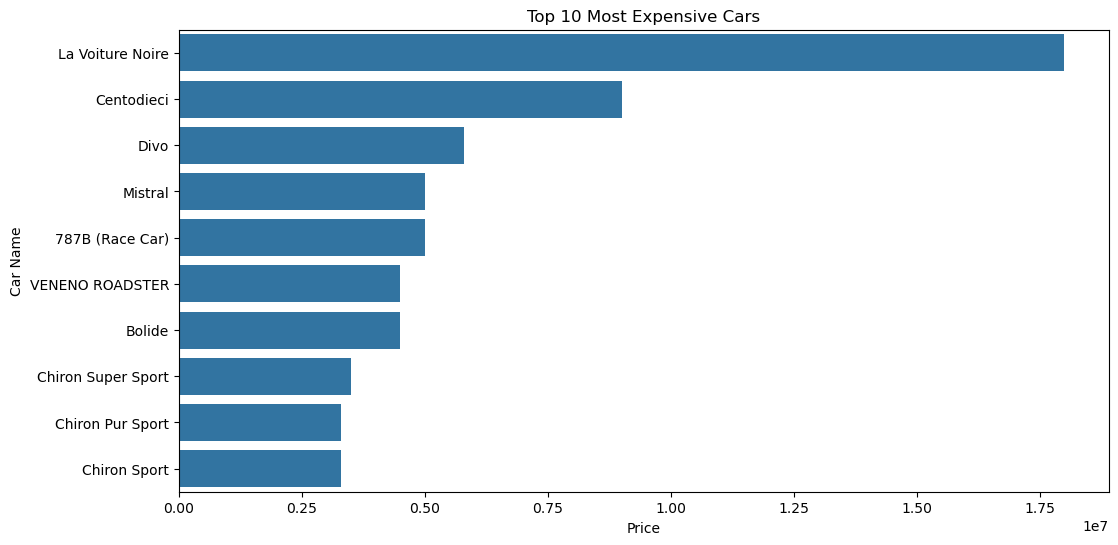

In [6]:
Top10 = df.nlargest(10, "Prices")
plt.figure(figsize = (12, 6))
sns.barplot(x = "Prices", y = "Cars Names", data = Top10)
plt.title("Top 10 Most Expensive Cars")
plt.xlabel("Price")
plt.ylabel("Car Name")

plt.show()

In [7]:
print(Top10[['Cars Names', 'Prices']])

              Cars Names      Prices
887     La Voiture Noire  18000000.0
886           Centodieci   9000000.0
885                 Divo   5800000.0
889              Mistral   5000000.0
1211     787B (Race Car)   5000000.0
8        VENENO ROADSTER   4500000.0
888               Bolide   4500000.0
882   Chiron Super Sport   3500000.0
881     Chiron Pur Sport   3300000.0
883         Chiron Sport   3300000.0


### Distribution of fuel types

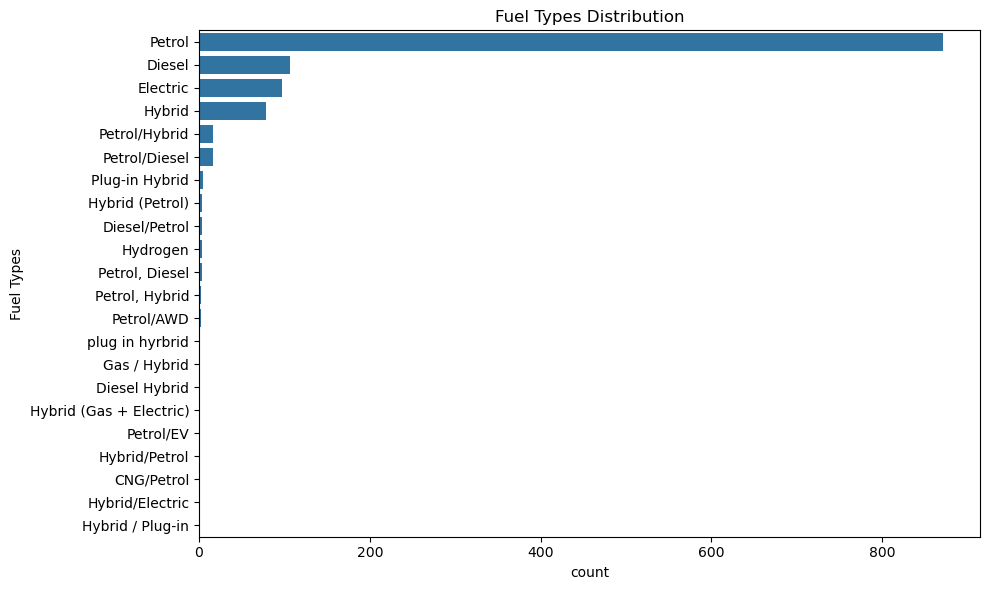

In [12]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="Fuel Types",
    data=df,
    order=df["Fuel Types"].value_counts().index
)

plt.title("Fuel Types Distribution")

plt.tight_layout()

plt.show()

### The relationship between speed and horsepower

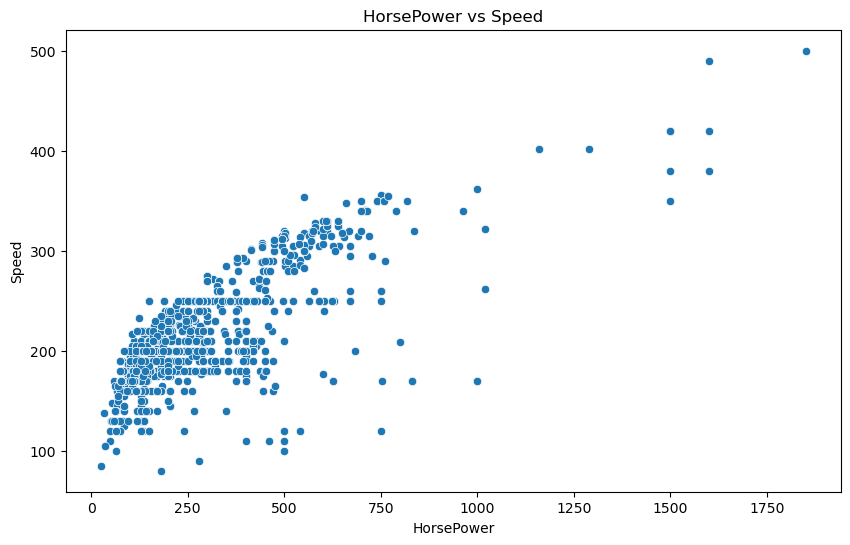

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="HorsePower",
    y="Total Speed (km/h)",
    data=df
)



plt.title("HorsePower vs Speed")
plt.xlabel("HorsePower")
plt.ylabel("Speed")

plt.show()

### Average prices by company

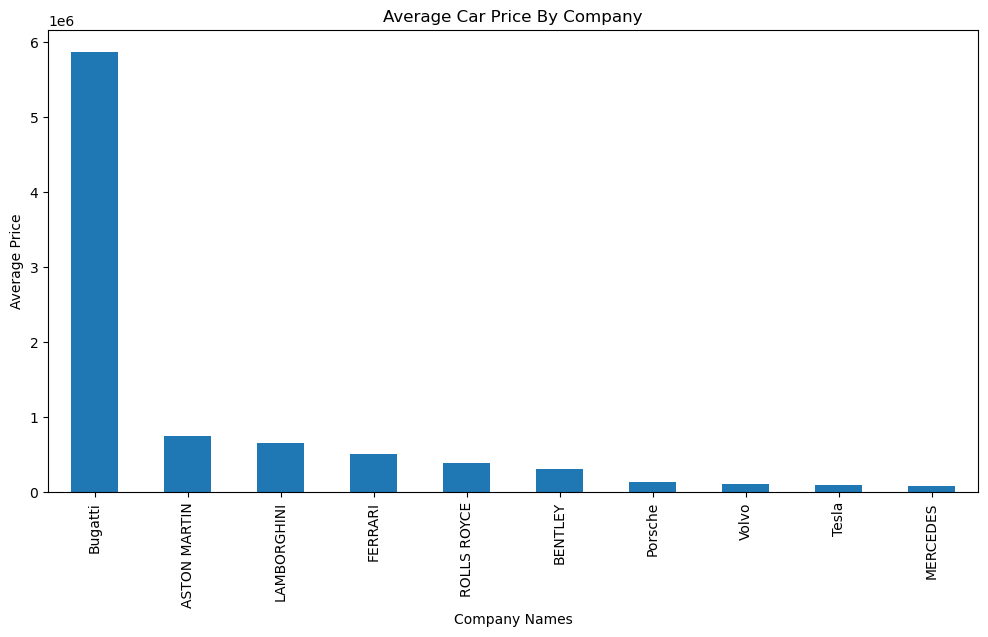

In [38]:
company_price = (
    df.groupby("Company Names")["Prices"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

company_price.plot(kind="bar")

plt.title("Average Car Price By Company")
plt.ylabel("Average Price")

plt.show()

### Correlation Heatmap

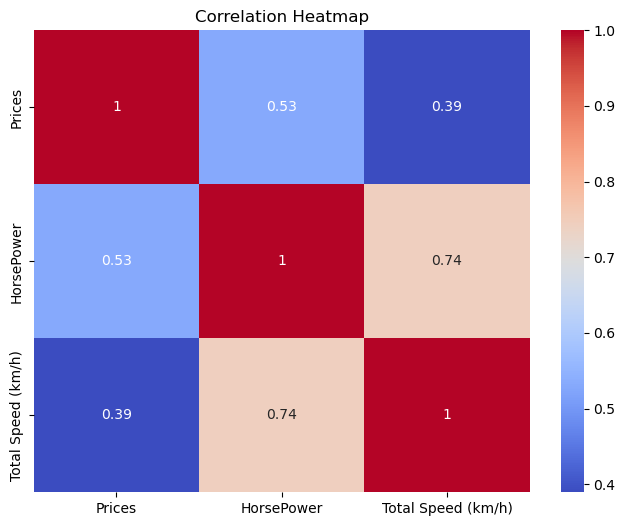

In [35]:
numeric_cols = df[[
    "Prices",
    "HorsePower",
    "Total Speed (km/h)"
]]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Top Companies by Average Speed

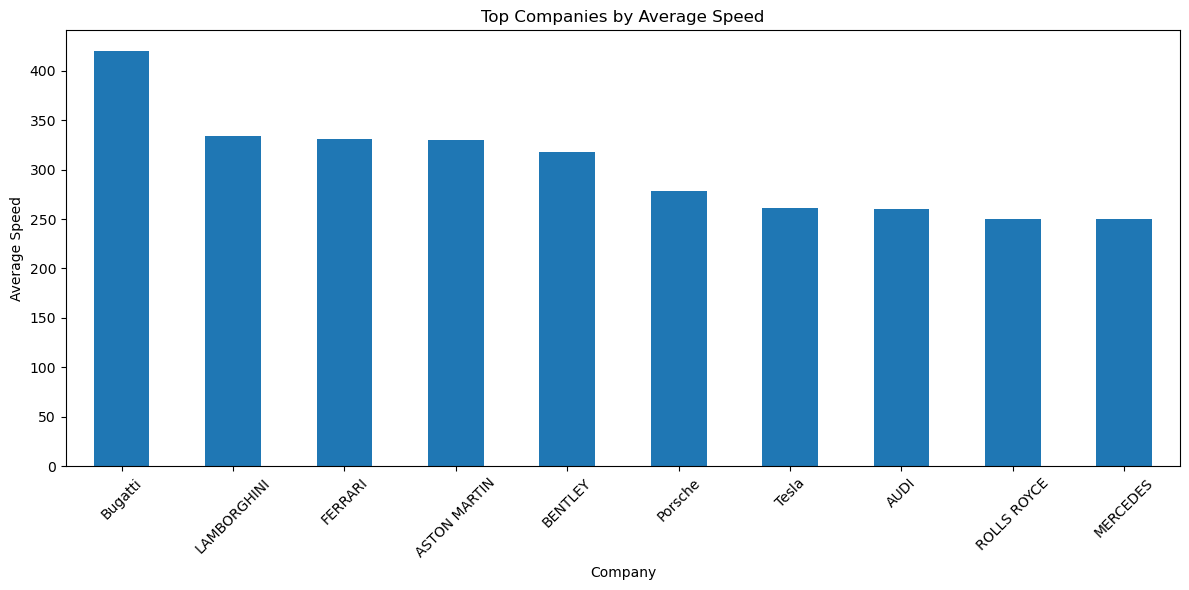

In [39]:
avg_speed = (
    df.groupby("Company Names")["Total Speed (km/h)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

avg_speed.plot(kind="bar")

plt.title("Top Companies by Average Speed")
plt.xlabel("Company")
plt.ylabel("Average Speed")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Horsepower vs Price

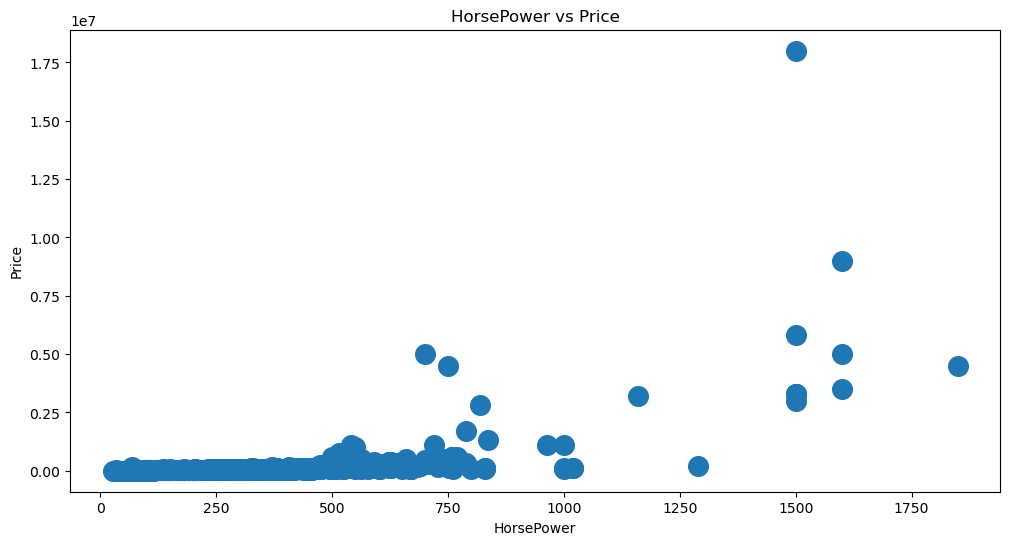

In [44]:
plt.figure(figsize=(12,6))

plt.scatter(
    df["HorsePower"],
    df["Prices"],
    s=200
)

plt.title("HorsePower vs Price")
plt.xlabel("HorsePower")
plt.ylabel("Price")

plt.show()